<a href="https://colab.research.google.com/github/encoras/Introduction-to-OpenCV/blob/master/amber_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Renkame duomenis iš nk01-nk12...


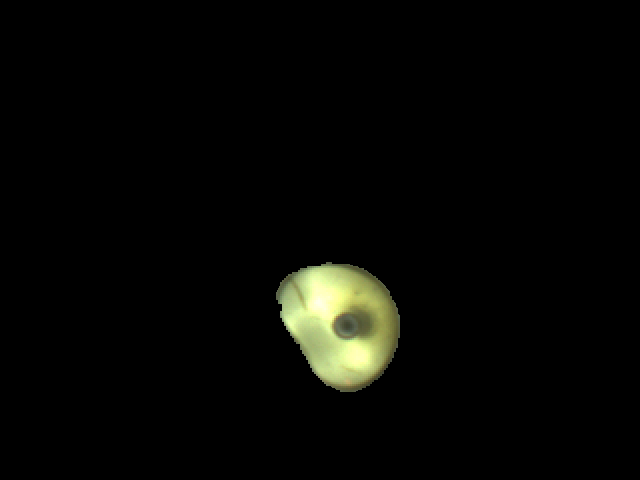

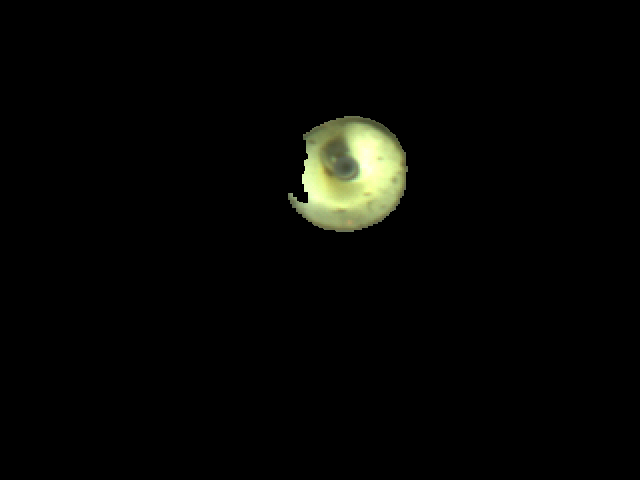

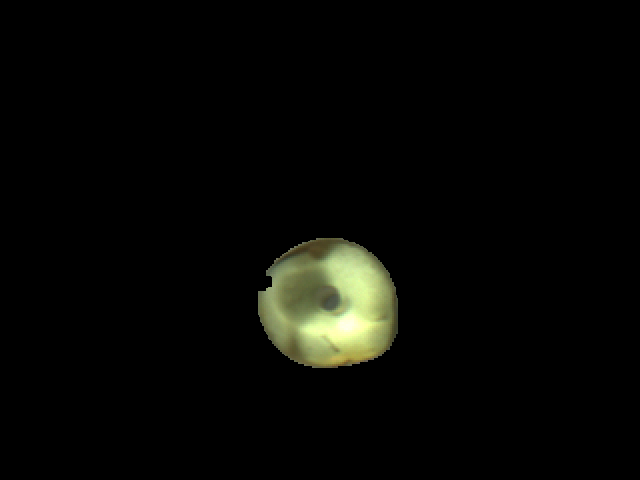

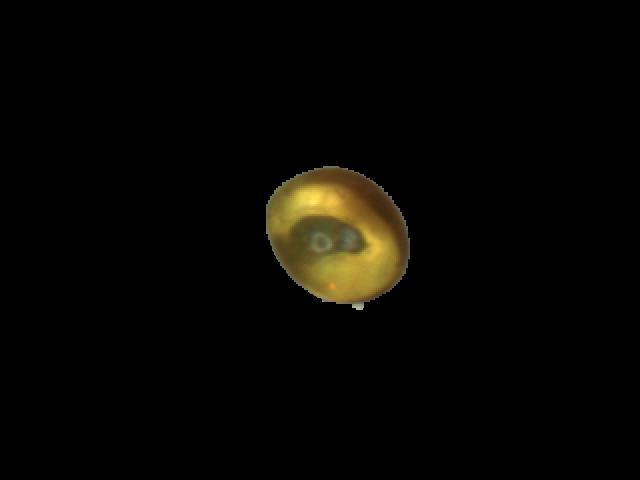

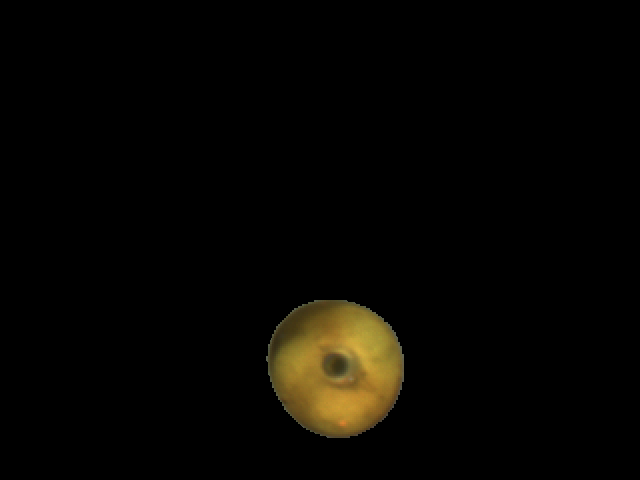

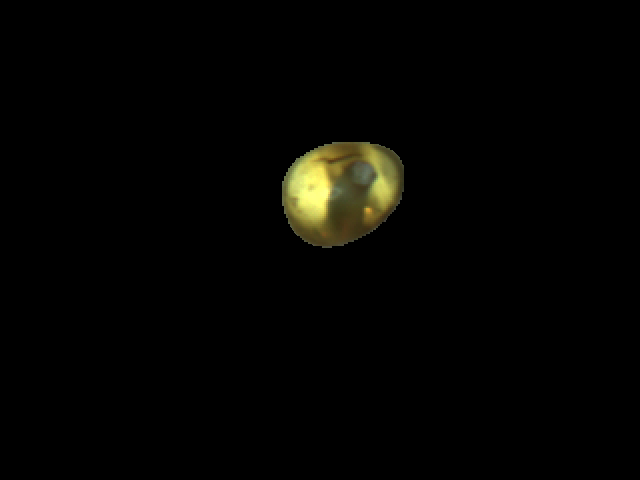

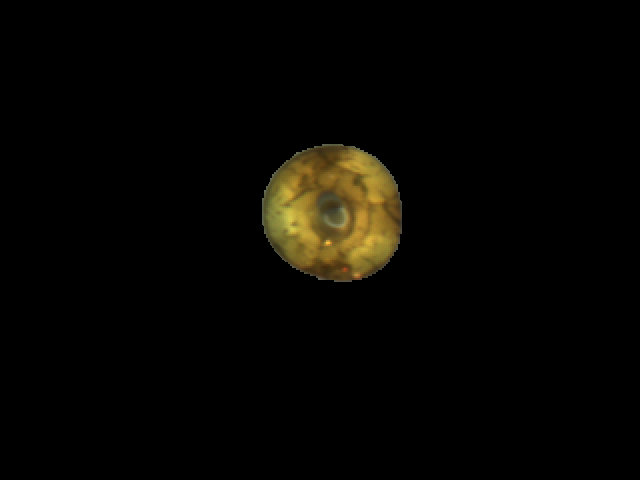

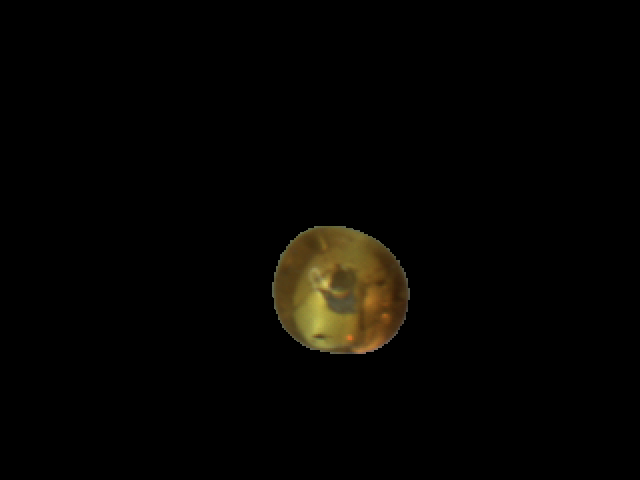

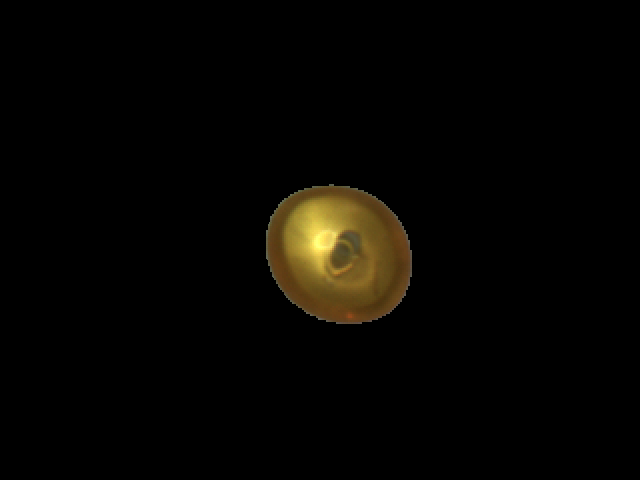

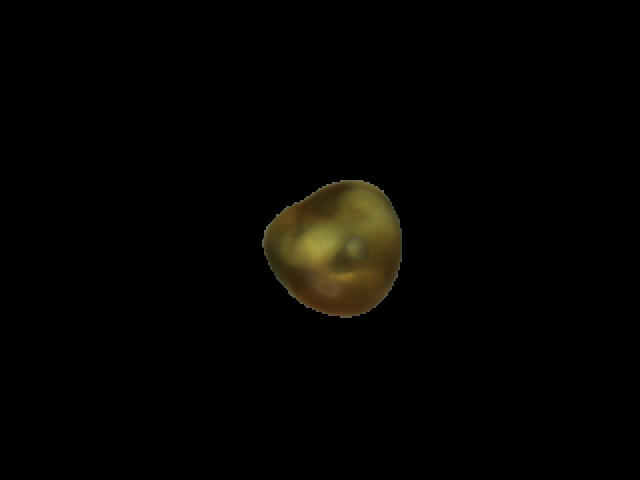

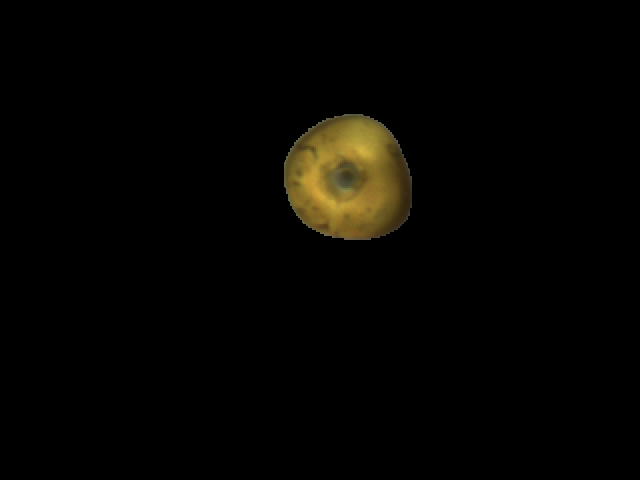

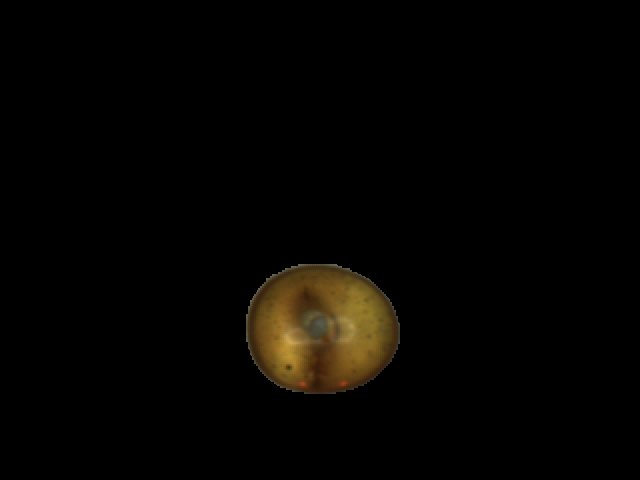

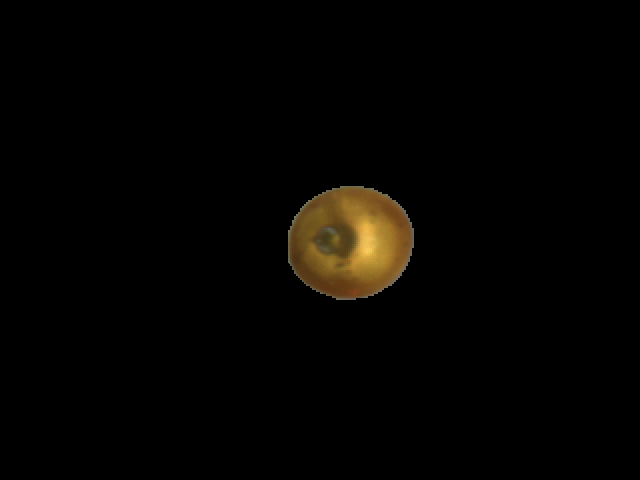

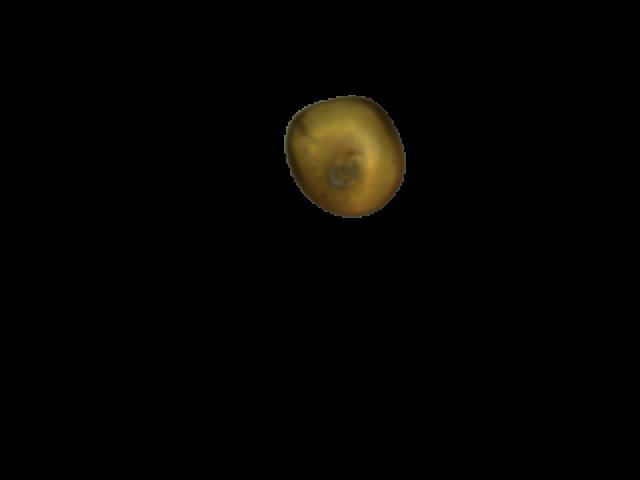

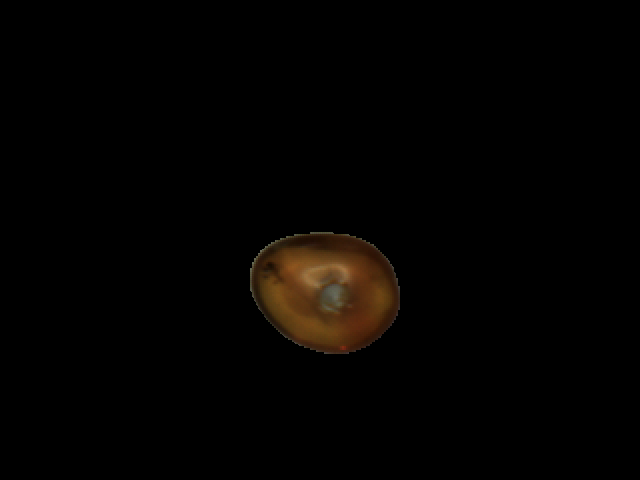

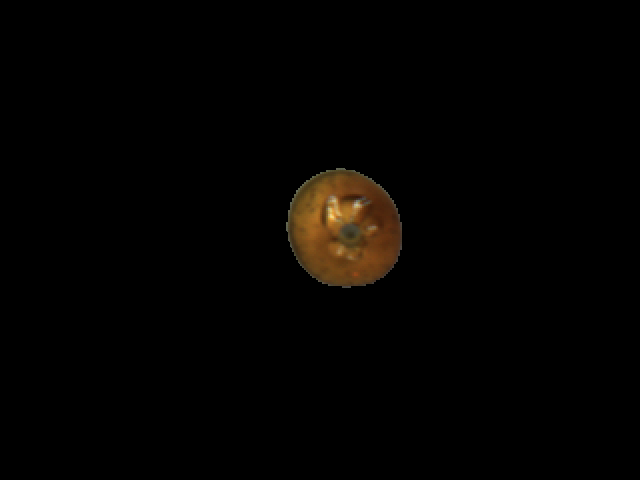

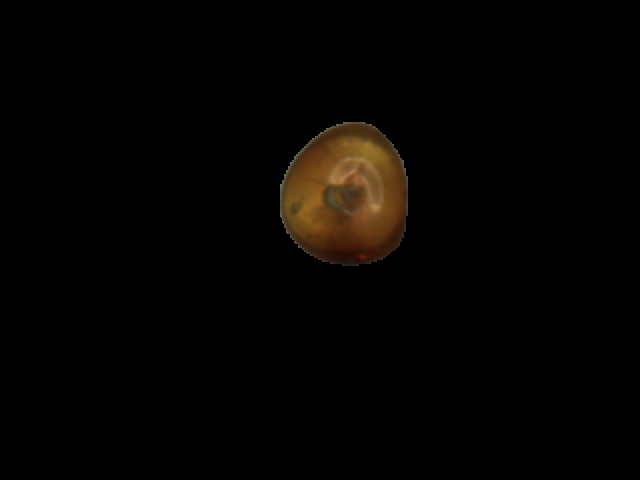

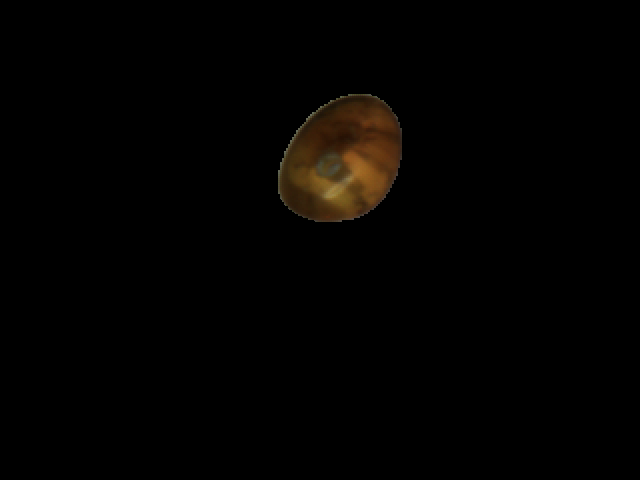

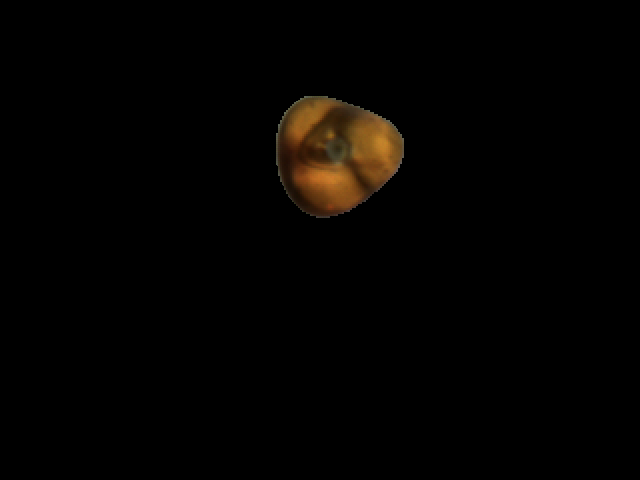

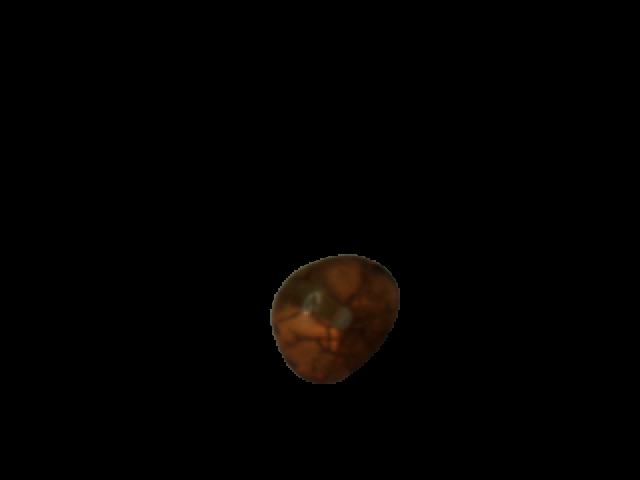

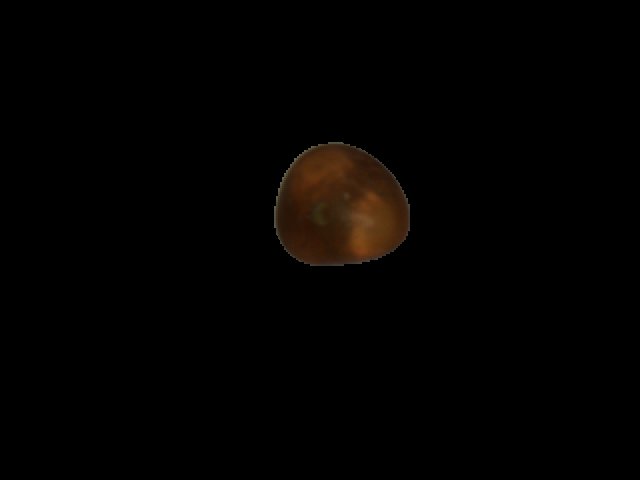

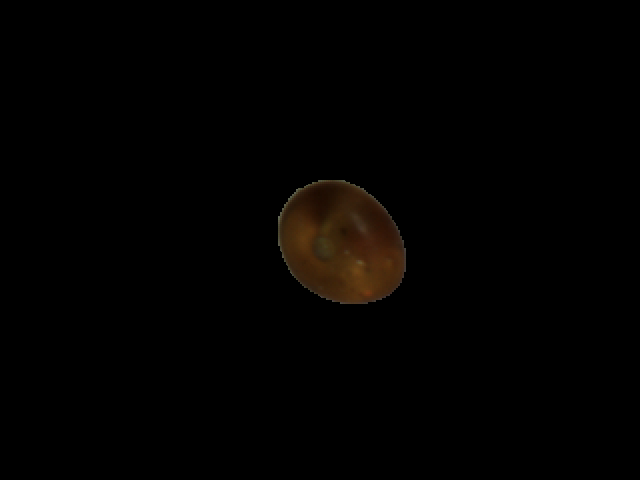

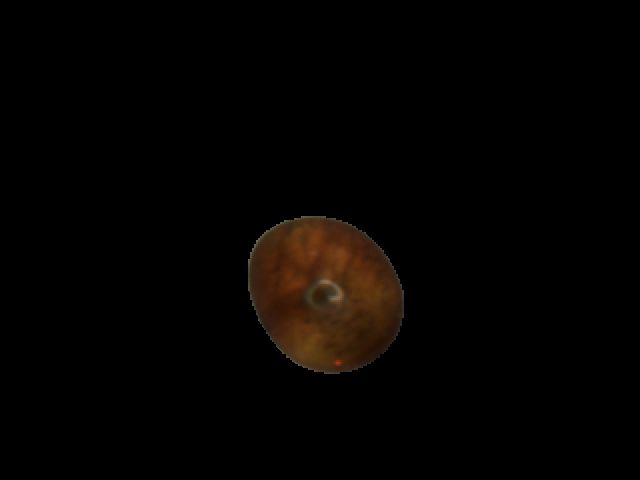

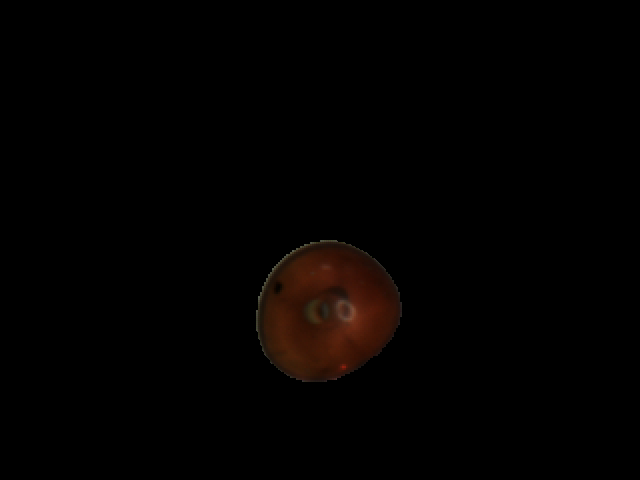

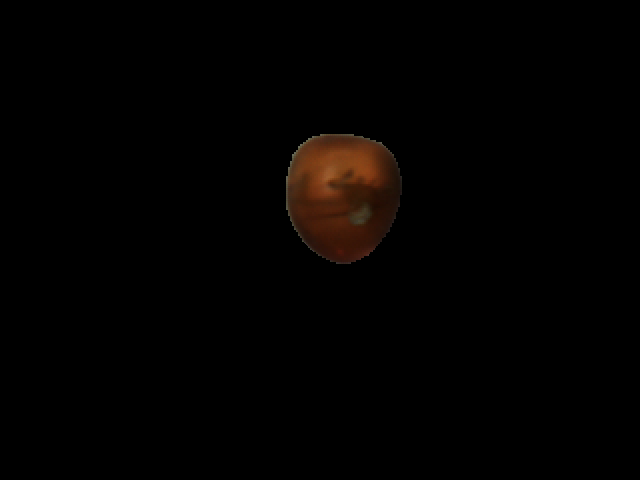

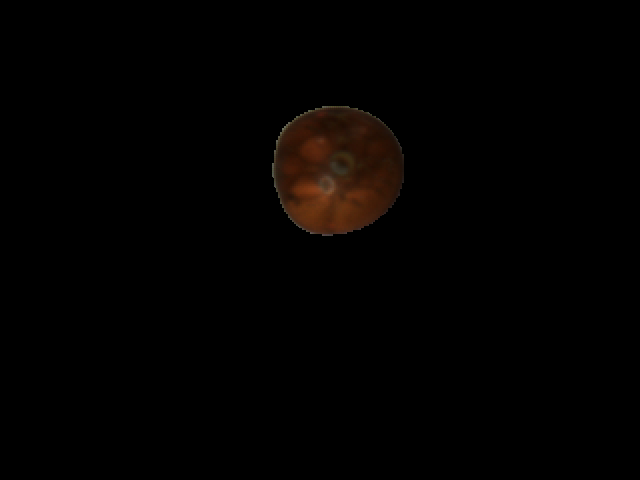

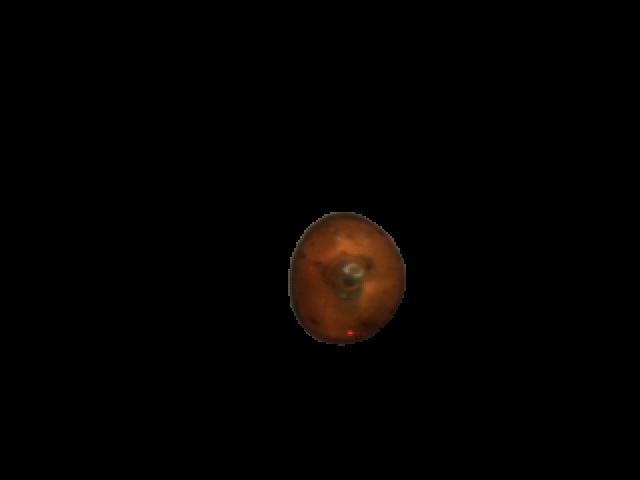

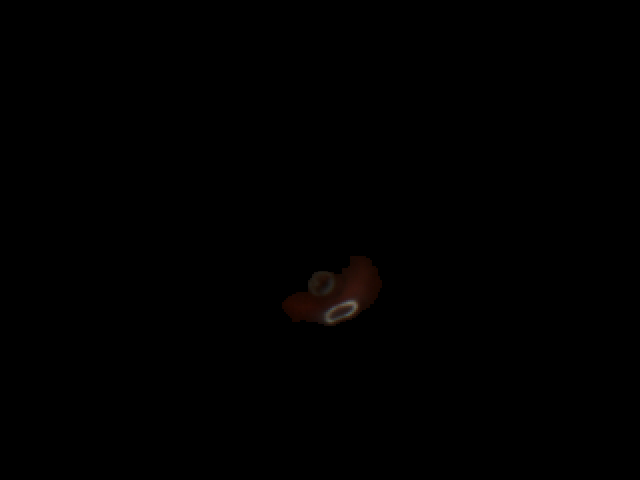

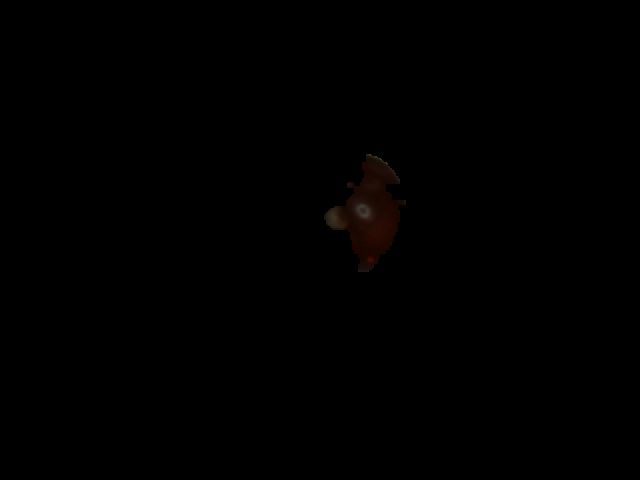

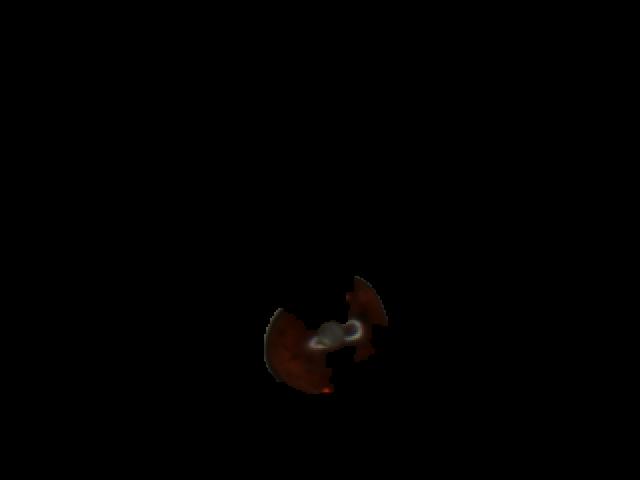

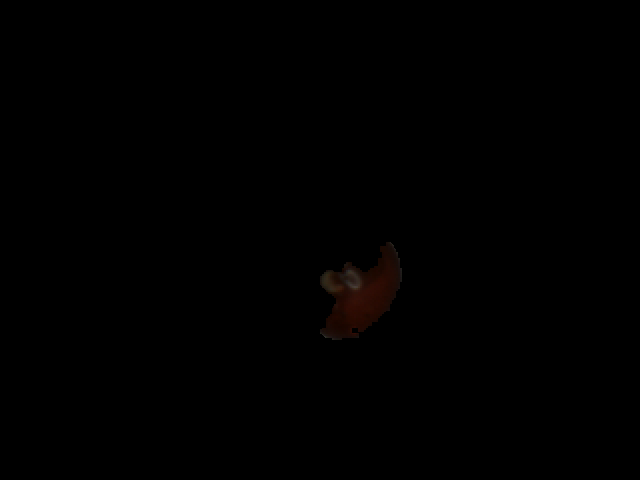

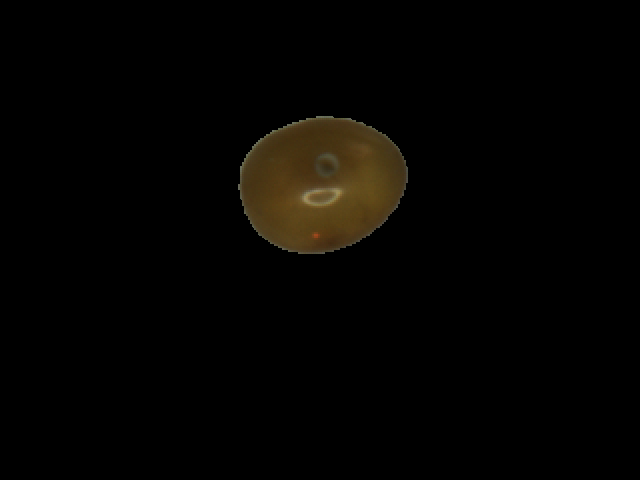

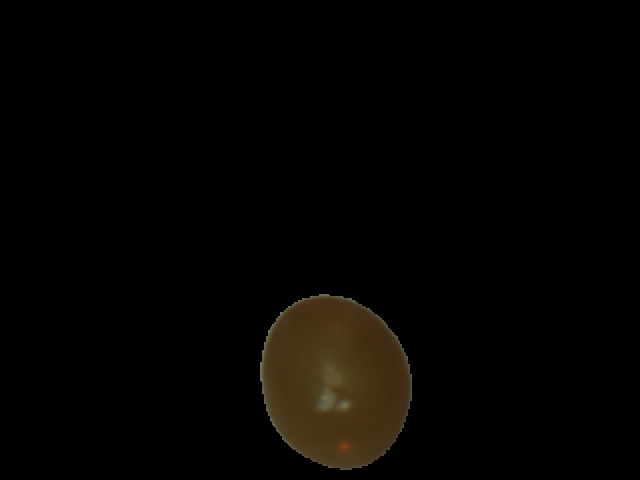

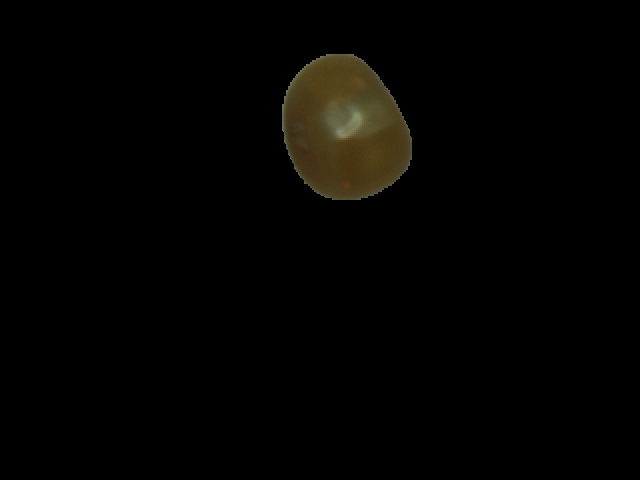

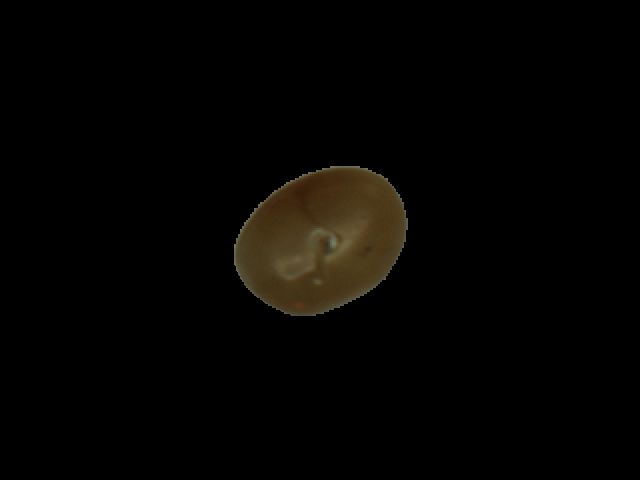

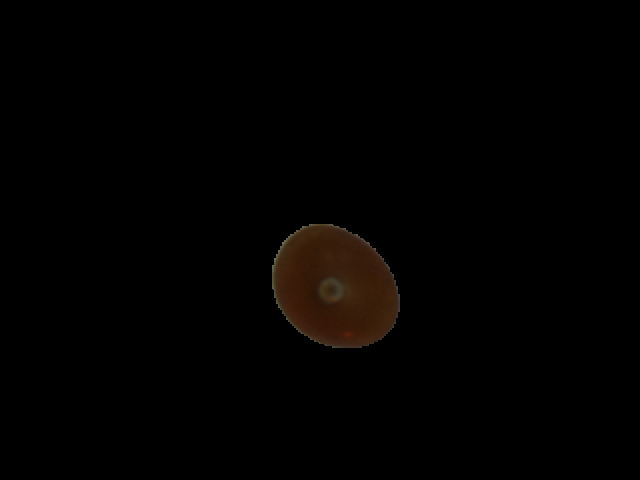

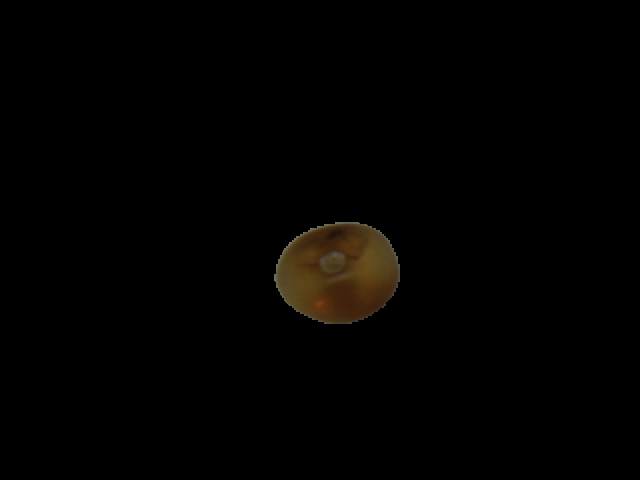

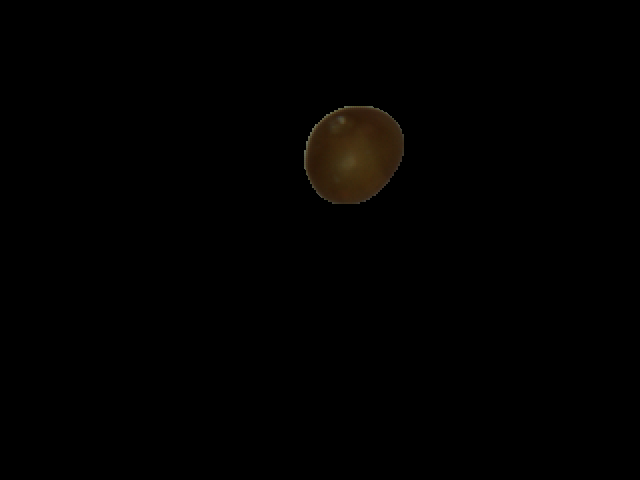

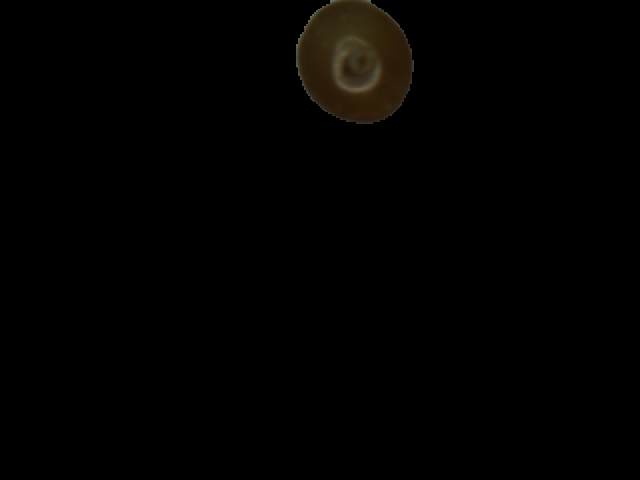

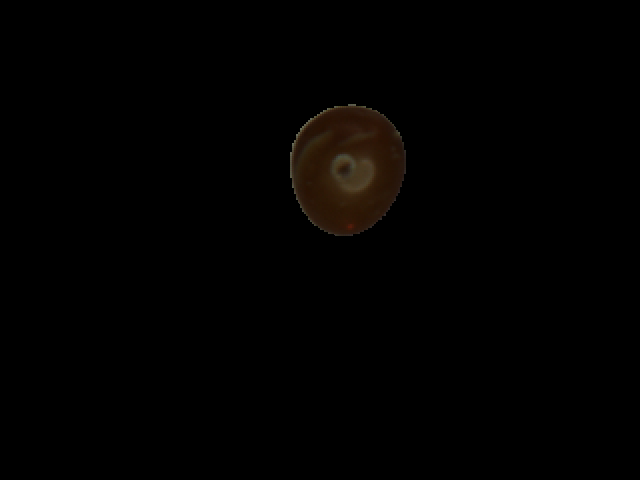

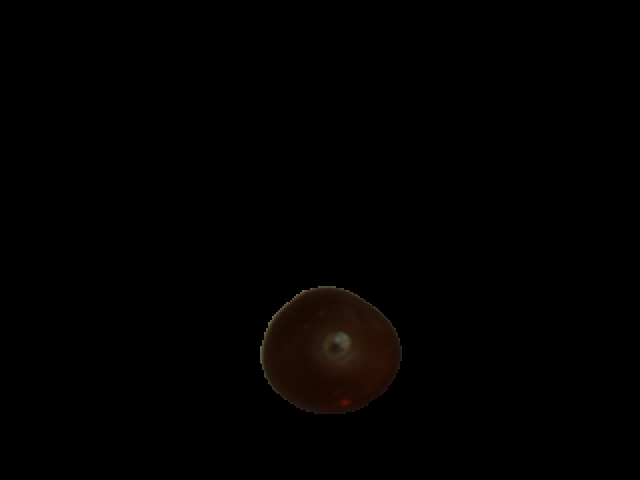

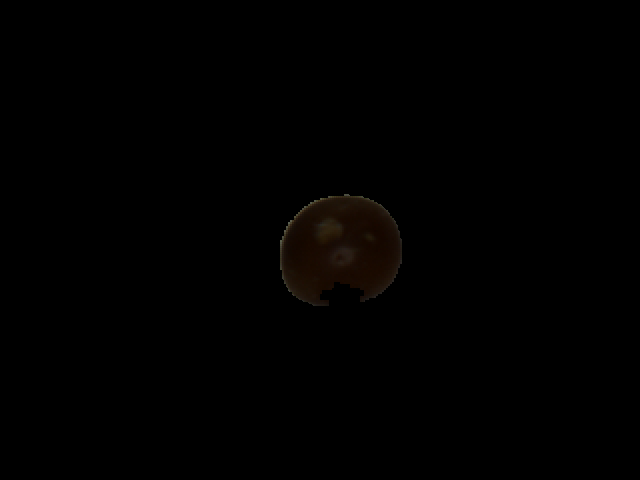

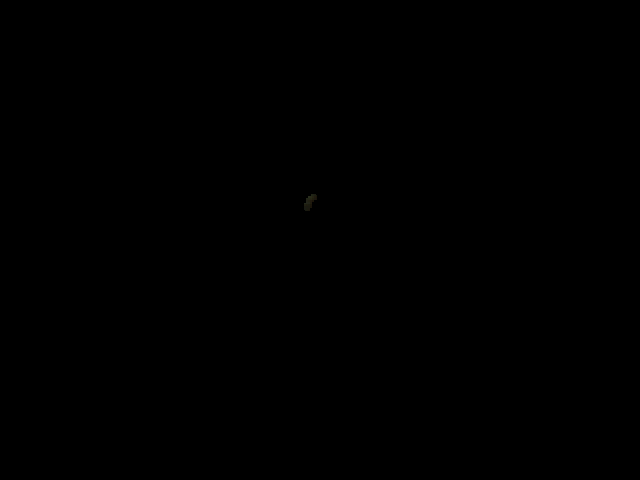

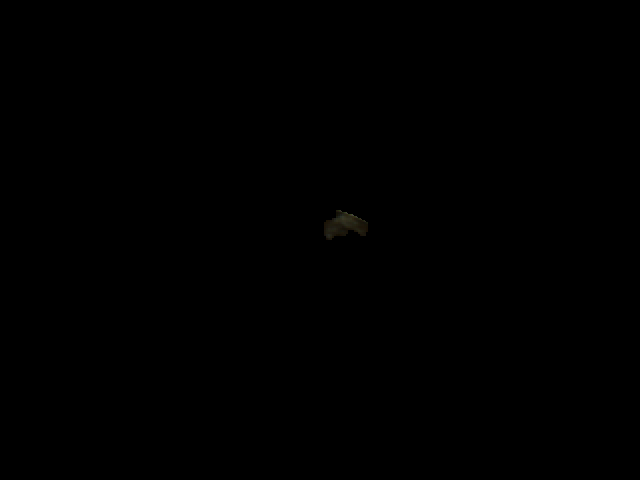

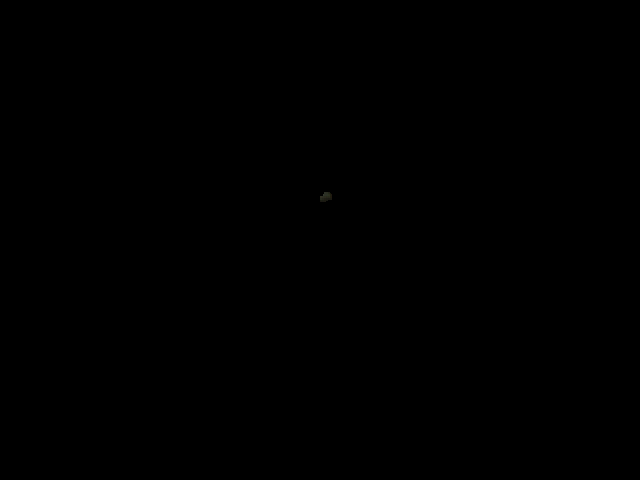

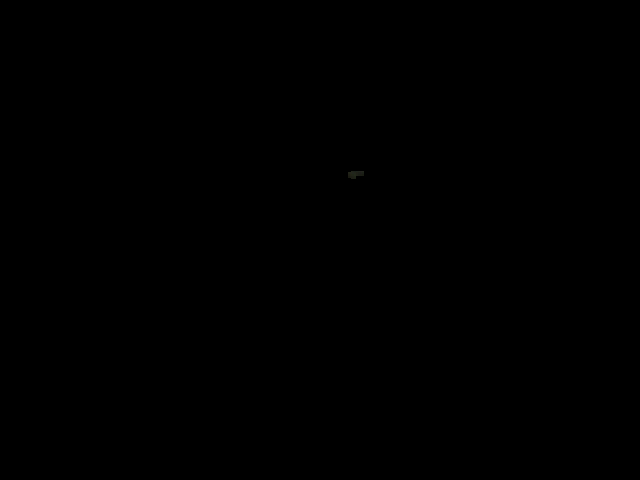

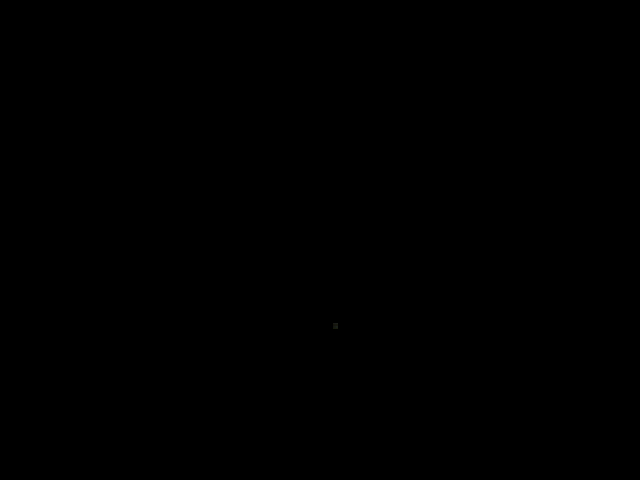

✅ Surinkta 2224 pavyzdžių iš 12 klasių


,mean_L,mean_A,mean_B,std_L,std_A,std_B,area,circularity,label
0,153.25,116.90,148.27,50.35,4.99,7.28,9693,0.45,NK01
1,162.66,116.26,156.80,40.84,4.14,10.26,9768,0.20,NK01
2,152.72,117.05,159.79,56.57,5.12,11.97,13976,0.79,NK01
3,189.61,114.60,158.43,58.63,5.29,10.19,12238,0.71,NK01
4,132.11,117.20,148.79,29.78,3.75,5.40,7433,0.72,NK01


In [10]:
# ========================== 1. INSTALIACIJA IR IMPORTAI ==========================
!pip install opencv-python-headless scikit-learn pandas matplotlib seaborn -q

import cv2
import numpy as np
import pandas as pd
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab.patches import cv2_imshow

# ========================== 2. KONFIGŪRACIJA ==========================
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/kevir_12_mazi"   # ← pakeisk į savo kelią

# HSV ribos gintarui (labai gerai veikia ant šviesaus fono)
LOWER_AMBER = np.array([ 6,  40,  25])   # H, S, V
UPPER_AMBER = np.array([ 40, 255, 255])

# Morfologija
KERNEL = np.ones((5,5), np.uint8)

# ========================== 3. SEGMENTAVIMO FUNKCIJA ==========================
def segment_amber(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return None, None

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LOWER_AMBER, UPPER_AMBER)

    # Valymas
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, KERNEL)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, KERNEL)

    # Imame didžiausią kontūrą (kad nebūtų triukšmo)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None

    largest = max(contours, key=cv2.contourArea)
    mask_clean = np.zeros(mask.shape, np.uint8)
    cv2.drawContours(mask_clean, [largest], -1, 255, -1)

    return img, mask_clean

# ========================== 4. FEATURE EXTRACTION (LAB) ==========================
def extract_features(img, mask):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    masked_lab = lab[mask > 0]

    if len(masked_lab) < 100:  # per mažas gabalėlis
        return None

    mean_l, mean_a, mean_b = np.mean(masked_lab, axis=0)
    std_l,  std_a,  std_b  = np.std(masked_lab, axis=0)

    # Papildomi požymiai
    area = np.sum(mask > 0)
    perimeter = cv2.arcLength(cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0][0], True)
    circularity = 4 * np.pi * area / (perimeter * perimeter + 1e-6)

    return {
        'mean_L': mean_l, 'mean_A': mean_a, 'mean_B': mean_b,
        'std_L':  std_l,  'std_A':  std_a,  'std_B':  std_b,
        'area': area, 'circularity': circularity
    }

# ========================== 5. DUOMENŲ SURINKIMAS (TRAINING) ==========================
features_list = []
labels = []

print("✅ Renkame duomenis iš nk01-nk12...")

for nk_folder in sorted(Path(DATASET_PATH).glob("NK*")):
    class_name = nk_folder.name
    for img_path in nk_folder.glob("*.*"):
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue

        img, mask = segment_amber(img_path)
        if img is None or mask is None:
            continue

        feat = extract_features(img, mask)
        if feat:
            features_list.append(feat)
            labels.append(class_name)

        # Parodome pirmus 3 pavyzdžius iš kiekvienos klasės
        if len(features_list) % 50 == 0:
            cv2_imshow(cv2.bitwise_and(img, img, mask=mask))

df = pd.DataFrame(features_list)
df['label'] = labels
print(f"✅ Surinkta {len(df)} pavyzdžių iš {len(df['label'].unique())} klasių")
df.head()

🎯 Tikslumas: 0.8237410071942446
              precision    recall  f1-score   support

        NK01       0.96      1.00      0.98        46
        NK02       0.85      0.83      0.84        48
        NK03       0.82      0.74      0.78        50
        NK04       0.70      0.82      0.75        49
        NK05       0.66      0.62      0.64        50
        NK06       0.63      0.59      0.61        49
        NK07       0.70      0.80      0.74        49
        NK08       0.96      0.92      0.94        49
        NK09       0.98      0.96      0.97        49
        NK10       0.86      0.88      0.87        49
        NK11       0.93      0.86      0.89        49
        NK12       0.95      1.00      0.97        19

    accuracy                           0.82       556
   macro avg       0.83      0.83      0.83       556
weighted avg       0.83      0.82      0.82       556



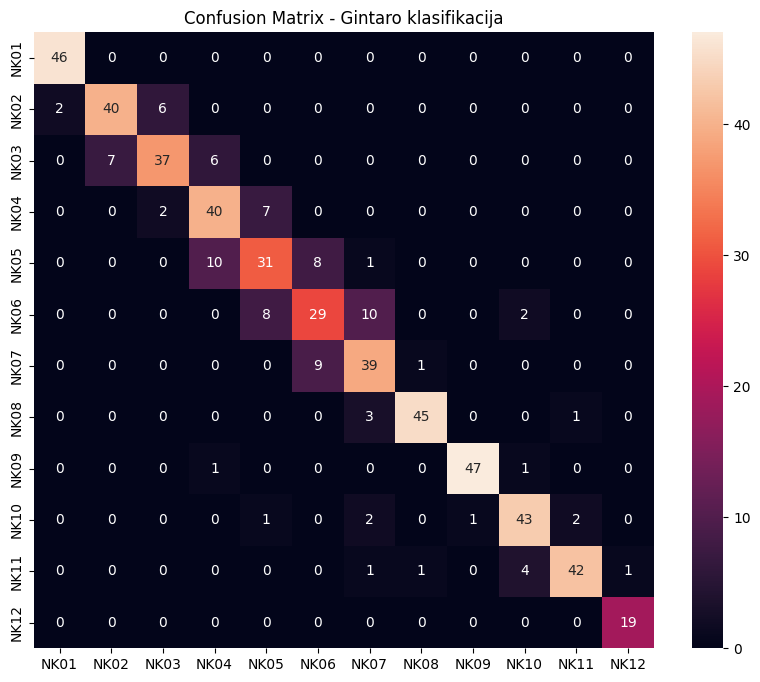

In [11]:
# ========================== MOKYMAS ==========================
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=300, max_depth=12,
                             random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# ========================== REZULTATAI ==========================
y_pred = clf.predict(X_test)
print("🎯 Tikslumas:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title("Confusion Matrix - Gintaro klasifikacija")
plt.show()

In [12]:
!pip install lazypredict

In [13]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)   # ← graži lentelė su ~30 modelių rezultatais

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1668, number of used features: 8
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.456536
[LightGBM] [Info] Start training from score -2.415434
[LightGBM] [Info] Start training from score -2.428948
[LightGBM] [Info] Start training from score -2.415434
[LightGBM] [Info] Start training from score -2.435774
[LightGBM] [Info] Start training from score -2.422168
[LightGBM] [Info] Start training from score -2.435774
[LightGBM] [Info] Start training from score -2.428948
[LightGBM] [Info] Start training from score -2.415434
[LightGBM] [Info] Start training from score -2.435774
[LightGBM] [Info] Start training from score -3.341843
[LightGBM] [Warning] No further splits with positive gain, best g